# 🌸 Dataset 2: Flowers Recognition — MobileNetV2 Transfer Learning
## Kỹ thuật: Transfer Learning + Fine-tuning

**Pipeline:** Dataset Analysis → Sample Visualization → Build MobileNetV2 → Train (Frozen) → Fine-tune → Evaluate

---

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

import random

SEED = 42

np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# (Optional) More deterministic behavior
os.environ["PYTHONHASHSEED"] = str(SEED)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.titlesize': 12, 'axes.titleweight': 'bold'})

DATA_DIR = '../data/flowers/flowers'
SAVE_DIR = '../results/flowers'
os.makedirs(SAVE_DIR, exist_ok=True)

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 15

print(f'TF: {tf.__version__}')

2026-05-28 12:09:02.574272: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-28 12:09:02.614713: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-28 12:09:03.150482: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


TF: 2.13.0


## 📊 1. Khám phá Dataset Flowers

In [2]:
classes = sorted(os.listdir(DATA_DIR))
class_counts = {c: len(os.listdir(os.path.join(DATA_DIR, c))) for c in classes}

print(f'Classes ({len(classes)}): {classes}')
total = sum(class_counts.values())
for c, n in class_counts.items():
    print(f'  {c:15s}: {n:,} images ({n/total*100:.1f}%)')
print(f'  Total         : {total:,}')

Classes (5): ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
  daisy          : 764 images (17.7%)
  dandelion      : 1,052 images (24.4%)
  rose           : 784 images (18.2%)
  sunflower      : 733 images (17.0%)
  tulip          : 984 images (22.8%)
  Total         : 4,317


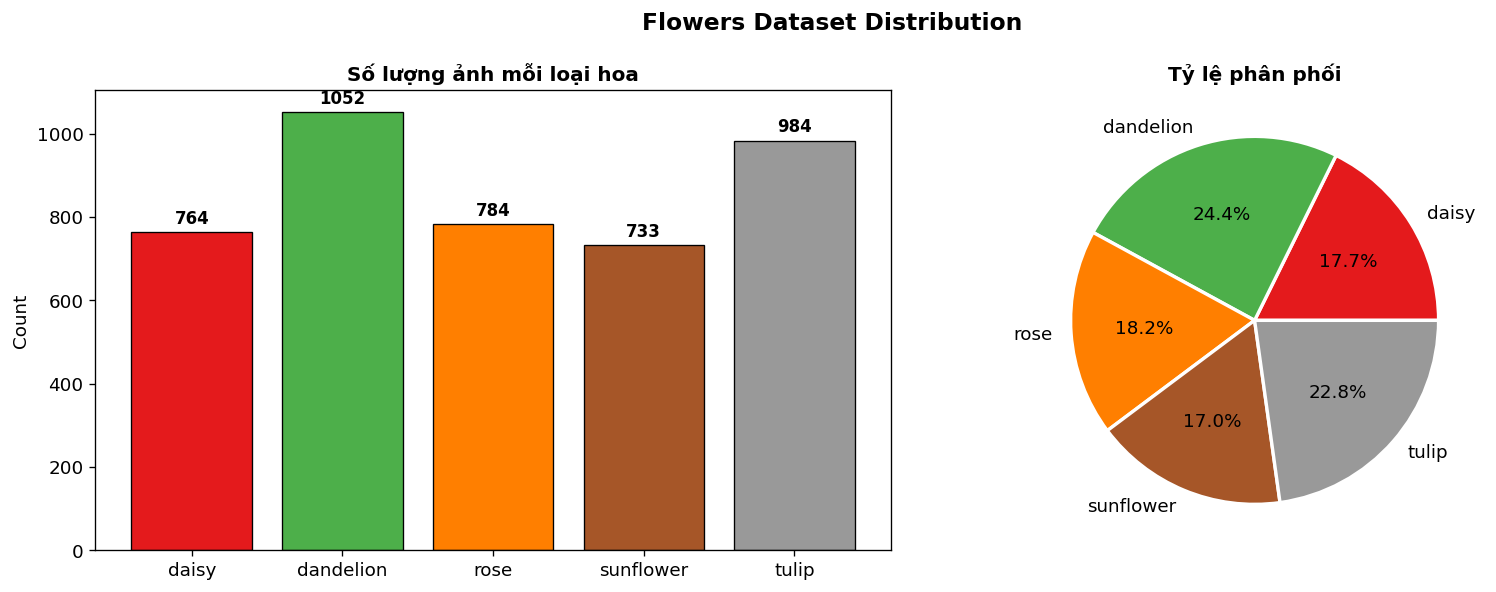

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = plt.cm.Set1(np.linspace(0, 1, len(classes)))
bars = axes[0].bar(class_counts.keys(), class_counts.values(),
                   color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Số lượng ảnh mỗi loại hoa')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, class_counts.values()):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                 f'{val}', ha='center', fontsize=10, fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct='%1.1f%%', colors=colors,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Tỷ lệ phân phối')

plt.suptitle('Flowers Dataset Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/01_class_distribution.png', bbox_inches='tight')
plt.show()

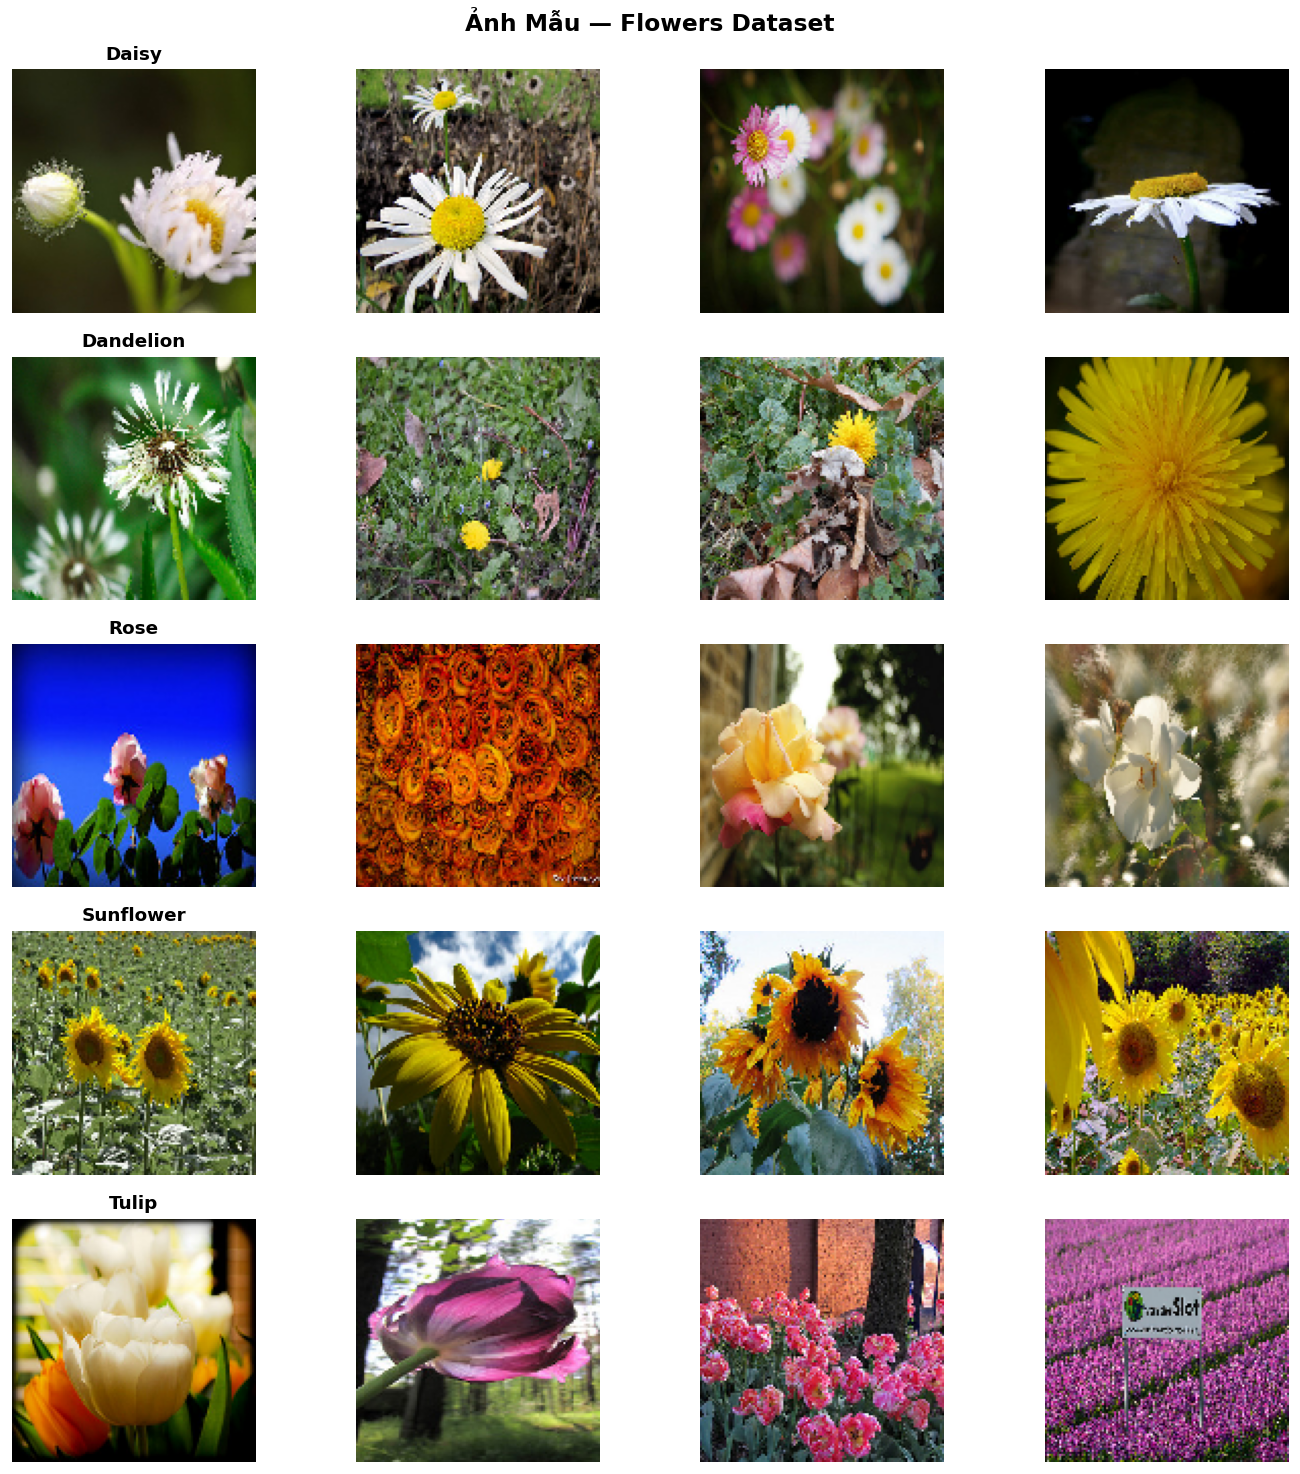

In [4]:
# Sample images
fig, axes = plt.subplots(len(classes), 4, figsize=(12, len(classes)*2.5))

for row, cls in enumerate(classes):
    cls_dir = os.path.join(DATA_DIR, cls)
    imgs    = [f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg','.jpeg','.png'))][:4]
    for col, img_name in enumerate(imgs):
        img = load_img(os.path.join(cls_dir, img_name), target_size=(120, 120))
        axes[row, col].imshow(img)
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(cls.capitalize(), fontweight='bold', fontsize=11)

plt.suptitle('Ảnh Mẫu — Flowers Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/02_sample_images.png', bbox_inches='tight')
plt.show()

## 🏗️ 2. Build MobileNetV2 — Transfer Learning

In [5]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.2,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2]
)

train_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', shuffle=True,
    seed=SEED)
val_gen = datagen.flow_from_directory(
    DATA_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', shuffle=False,
    seed=SEED)

NUM_CLASSES = len(classes)

print("Classes:", classes)
print("Num Classes:", NUM_CLASSES)

Found 3457 images belonging to 5 classes.
Found 860 images belonging to 5 classes.
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']
Num Classes: 5


In [6]:
# Stage 1: Frozen base
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
], name='MobileNetV2_Flowers')

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])

print(f'Trainable params (frozen base): {model.count_params():,}')
trainable = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f'  → Trainable only: {trainable:,}')

2026-05-28 12:09:07.474108: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-28 12:09:07.894644: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-28 12:09:07.898357: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:995] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Trainable params (frozen base): 2,592,325
  → Trainable only: 331,781


In [7]:
# Stage 1 training
hist1 = model.fit(
    train_gen, epochs=15, validation_data=val_gen,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)
print(f'Stage 1 best val_acc: {max(hist1.history["val_accuracy"]):.4f}')

Epoch 1/15
 15/109 [===>..........................] - ETA: 18s - loss: 1.1182 - accuracy: 0.6333

109/109 [==============================] - 28s 249ms/step - loss: 0.7329 - accuracy: 0.7692 - val_loss: 0.5052 - val_accuracy: 0.8349
Epoch 2/15
109/109 [==============================] - 27s 243ms/step - loss: 0.4029 - accuracy: 0.8629 - val_loss: 0.4405 - val_accuracy: 0.8337
Epoch 3/15
109/109 [==============================] - 26s 242ms/step - loss: 0.3436 - accuracy: 0.8814 - val_loss: 0.4114 - val_accuracy: 0.8581
Epoch 4/15
109/109 [==============================] - 26s 243ms/step - loss: 0.2913 - accuracy: 0.8933 - val_loss: 0.4328 - val_accuracy: 0.8558
Epoch 5/15
109/109 [==============================] - 27s 244ms/step - loss: 0.2553 - accuracy: 0.9074 - val_loss: 0.4364 - val_accuracy: 0.8535
Epoch 6/15
109/109 [==============================] - 27s 243ms/step - loss: 0.2280 - accuracy: 0.9138 - val_loss: 0.3928 - val_accuracy: 0.8593
Epoch 7/15
109/109 [==============================] - 26s 242ms/step - loss: 0.2097 - accuracy: 0.9228 - val_loss: 0.4439 - val_accuracy: 0.8

In [8]:
# Stage 2: Fine-tuning — unfreeze last 30 layers
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

trainable2 = sum(tf.keras.backend.count_params(w) for w in model.trainable_weights)
print(f'Fine-tuning trainable params: {trainable2:,}')

hist2 = model.fit(
    train_gen, epochs=EPOCHS, validation_data=val_gen,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=4, restore_best_weights=True)],
    verbose=1)

Fine-tuning trainable params: 1,858,181
Epoch 1/15
109/109 [==============================] - 30s 254ms/step - loss: 0.3610 - accuracy: 0.8756 - val_loss: 0.4718 - val_accuracy: 0.8674
Epoch 2/15
109/109 [==============================] - 27s 248ms/step - loss: 0.3115 - accuracy: 0.8872 - val_loss: 0.4876 - val_accuracy: 0.8721
Epoch 3/15
109/109 [==============================] - 27s 247ms/step - loss: 0.2804 - accuracy: 0.8964 - val_loss: 0.4767 - val_accuracy: 0.8791
Epoch 4/15
109/109 [==============================] - 27s 246ms/step - loss: 0.2396 - accuracy: 0.9152 - val_loss: 0.4757 - val_accuracy: 0.8698
Epoch 5/15
109/109 [==============================] - 27s 246ms/step - loss: 0.2268 - accuracy: 0.9167 - val_loss: 0.4474 - val_accuracy: 0.8733
Epoch 6/15
109/109 [==============================] - 27s 247ms/step - loss: 0.2090 - accuracy: 0.9228 - val_loss: 0.4245 - val_accuracy: 0.8674
Epoch 7/15
109/109 [==============================] - 27s 246ms/step - loss: 0.2038 - accu

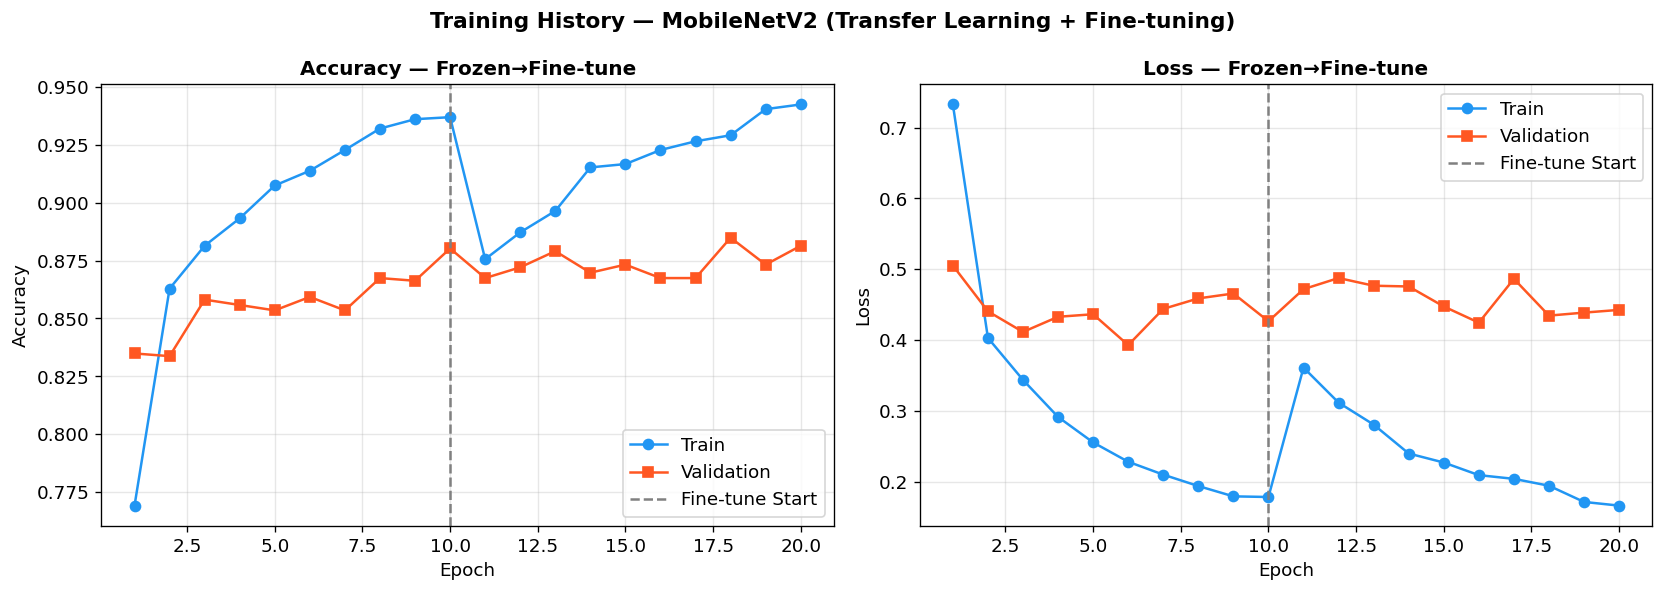

Best val acc: 0.8849


In [9]:
# Merge and plot history
all_acc     = hist1.history['accuracy']     + hist2.history['accuracy']
all_val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
all_loss    = hist1.history['loss']         + hist2.history['loss']
all_val_loss= hist1.history['val_loss']     + hist2.history['val_loss']
sep_ep = len(hist1.history['accuracy'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (train_h, val_h, ylabel) in zip(axes, [
    (all_acc,  all_val_acc,  'Accuracy'),
    (all_loss, all_val_loss, 'Loss')
]):
    eps = range(1, len(train_h)+1)
    ax.plot(eps, train_h, 'o-', color='#2196F3', label='Train')
    ax.plot(eps, val_h,   's-', color='#FF5722', label='Validation')
    ax.axvline(sep_ep, linestyle='--', color='gray', label='Fine-tune Start')
    ax.set_title(f'{ylabel} — Frozen→Fine-tune')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Training History — MobileNetV2 (Transfer Learning + Fine-tuning)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/03_training_history.png', bbox_inches='tight')
plt.show()
print(f'Best val acc: {max(all_val_acc):.4f}')

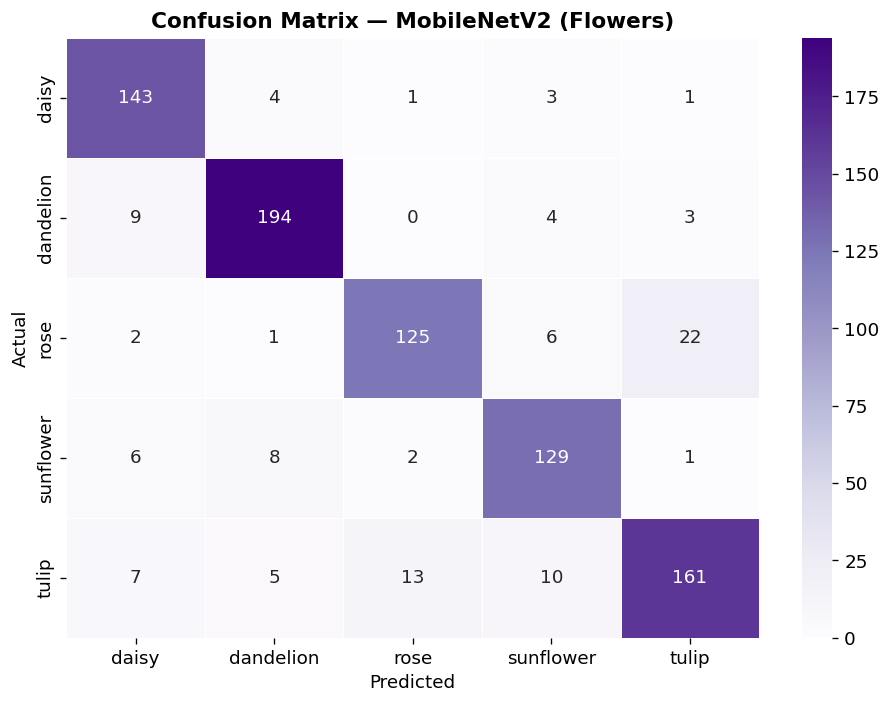

              precision    recall  f1-score   support

       daisy       0.86      0.94      0.90       152
   dandelion       0.92      0.92      0.92       210
        rose       0.89      0.80      0.84       156
   sunflower       0.85      0.88      0.87       146
       tulip       0.86      0.82      0.84       196

    accuracy                           0.87       860
   macro avg       0.87      0.87      0.87       860
weighted avg       0.87      0.87      0.87       860



In [10]:
# Evaluate & Confusion Matrix
val_gen.reset()
y_pred_prob = model.predict(val_gen, verbose=0)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = val_gen.classes

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=classes, yticklabels=classes, linewidths=0.5, ax=ax)
ax.set_title('Confusion Matrix — MobileNetV2 (Flowers)', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/04_confusion_matrix.png', bbox_inches='tight')
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

In [11]:
best_val_acc = max(all_val_acc)
with open(f'{SAVE_DIR}/report.txt', 'w') as f:
    f.write('Flowers Classification — MobileNetV2 Transfer Learning\n' + '='*55 + '\n')
    f.write(f'Best Val Accuracy: {best_val_acc:.4f}\n')
    f.write(f'Total Params: {model.count_params():,}\n\n')
    f.write(classification_report(y_true, y_pred, target_names=classes))

print('✅ Flowers MobileNetV2 Experiment Completed! Results saved to', SAVE_DIR)

✅ Flowers MobileNetV2 Experiment Completed! Results saved to ../results/flowers
